In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd

OUT_DIR = "/content/drive/MyDrive/CICIDS2017/processed"

In [3]:
#Load the files
X_train = pd.read_csv(os.path.join(OUT_DIR, "train1.csv"))
X_test = pd.read_csv(os.path.join(OUT_DIR, "test1.csv"))

y_train = pd.read_csv(
    os.path.join(OUT_DIR, "y_train.csv")
).squeeze("columns")

y_test = pd.read_csv(
    os.path.join(OUT_DIR, "y_test.csv")
).squeeze("columns")

In [4]:
#Check the shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2016638, 72)
X_test: (504160, 72)
y_train: (2016638,)
y_test: (504160,)


In [5]:
import os
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [6]:
print("Training labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training labels:
Binary_Label
0    1676045
1     340593
Name: count, dtype: int64

Testing labels:
Binary_Label
0    419012
1     85148
Name: count, dtype: int64


In [9]:
# Find columns containing text values
text_columns = X_train.select_dtypes(include=["object"]).columns

print("Text columns:", list(text_columns))

Text columns: ['Attack_Category']


In [10]:
X_train = X_train.drop(columns=["Attack_Category"], errors="ignore")
X_test = X_test.drop(columns=["Attack_Category"], errors="ignore")

In [11]:
print(X_train.select_dtypes(include=["object"]).columns)
print(X_test.select_dtypes(include=["object"]).columns)

Index([], dtype='object')
Index([], dtype='object')


In [12]:
print("Non-numeric columns in X_train:")
print(X_train.select_dtypes(exclude=["number"]).columns)

Non-numeric columns in X_train:
Index([], dtype='object')


In [13]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=100,
    solver="lbfgs",
    n_jobs=-1
)

logistic_model.fit(X_train, y_train)

LogisticRegression(n_jobs=-1)

In [14]:
y_pred = logistic_model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9999761980323707
Accuracy percentage: 99.99761980323707 %


In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["BENIGN", "ATTACK"]
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    419012
      ATTACK       1.00      1.00      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[419009      3]
 [     9  85139]]


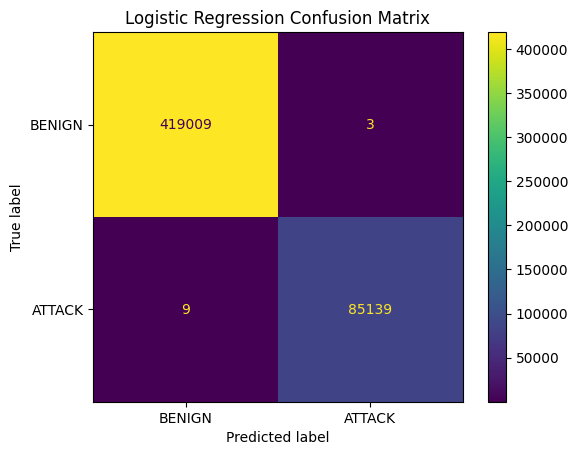

In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [19]:
import joblib
import os

MODEL_PATH = os.path.join(
    OUT_DIR,
    "logistic_regression_model.pkl"
)

joblib.dump(logistic_model, MODEL_PATH)

print("Model saved at:", MODEL_PATH)

Model saved at: /content/drive/MyDrive/CICIDS2017/processed/logistic_regression_model.pkl
